In [1]:
# OPENING IMPORTS

import numpy as np
from matplotlib import pyplot as plt
import xarray as xr

import zipfile as zp          # used for unzipping ppi files
from pathlib import Path      # used to play with pathnames to save 
from datetime import datetime # used to manipulate time :)

import wradlib as wr          # used for having fun with radar data

from PIL import Image         # used for creating gif loops
import os                     # used for retrieving file names

import h5py                   # used for reading .h5 files (Radar Level 1 data)
import h5netcdf               # used for converting .h5 files to NetCDF

# TAKEN FROM "Part4IntroductionToGridding"
import cartopy.crs as ccrs
import pyart
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
# FUNCTION
#pcolormesh but takes 1D X and Y coordinates for centres of the pixels

def pcolormeshC(x_centers, y_centers, z, ax=None,
                            shading='auto', **pcolor_kwargs):
    """
    Create a pcolormesh from a 2D array and 1D coordinate-center arrays.

    Parameters
    ----------
    x_centers : 1D array
        X coordinates of cell centers (length = number of columns in z)
    y_centers : 1D array
        Y coordinates of cell centers (length = number of rows in z)
    z : 2D array
        Data array with shape (len(y_centers), len(x_centers))
    ax : matplotlib.axes.Axes, optional
        Existing axis to draw on
    shading : str
        Passed to pcolormesh (default: 'auto')
    **pcolor_kwargs
        Extra kwargs passed to pcolormesh

    Returns
    -------
    pcm : QuadMesh
        The pcolormesh object
    """

    x_centers = np.asarray(x_centers)
    y_centers = np.asarray(y_centers)
    z = np.asarray(z)

    if z.shape != (len(y_centers), len(x_centers)):
        raise ValueError(
            f"z shape {z.shape} does not match "
            f"(len(y_centers), len(x_centers)) = "
            f"({len(y_centers)}, {len(x_centers)})"
        )

    # Convert centers -> edges
    def centers_to_edges(c):
        dc = np.diff(c)

        edges = np.empty(len(c) + 1)

        # Interior edges
        edges[1:-1] = c[:-1] + dc / 2

        # Extrapolate outer edges
        edges[0] = c[0] - dc[0] / 2
        edges[-1] = c[-1] + dc[-1] / 2

        return edges

    x_edges = centers_to_edges(x_centers)
    y_edges = centers_to_edges(y_centers)

    if ax is None:
        fig, ax = plt.subplots()

    pcm = ax.pcolormesh(
        x_edges,
        y_edges,
        z,
        shading=shading,
        **pcolor_kwargs
    )

    ax.set_xlabel("X")
    ax.set_ylabel("Y")

    return pcm

In [52]:
# THIS BLOCK IS WHERE THE USER PUTS INFO ABOUT THE RADAR

# the reference number for the radar location (ie 22 is Mackay)
RadarIDno = '22'  # 22 is Mackay, 106 is Townsville, 66 is Mt Staplyton (Brisbane) , 50 is Marabong (near Bris)
GridOrPPI = 'ppi'

if (RadarIDno == '22'):
    RadarSiteName = 'Mackay'
elif (RadarIDno == '106'):
    RadarSiteName = 'Townsville'
elif (RadarIDno == '66'):
    RadarSiteName = 'Mt Staplyton'
elif (RadarIDno == '50'):
    RadarSiteName = 'Marabong'
else:
    RadarSiteName = 'Site ' + RadarIDno

# the day in consideration (YYYYMMDD) and time (hhmmss)
# ALL IN UTC !!!
RadarYear  = 2024
RadarMonth = 2
RadarDay   = 14

RadarFileDate  = str(RadarYear).zfill(4) + str(RadarMonth).zfill(2) + str(RadarDay).zfill(2)
RadarFileTime =   '000000'

In [4]:
# THIS BLOCK TAKES A ZIPPED FOLDER FROM /G/DATA/ AND UNZIPS IT TO A FOLDER "nzippedRadarFiles" IN SCRATCH

# PATH NAMES
# ZippedFolder = '/g/data/rq0/level_1b/22/ppi/2024/'
ZippedFolder = '/g/data/rq0/level_1b/' + RadarIDno + '/' + GridOrPPI + '/' + str(RadarYear) + '/'
ZippedFile   =  RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '.zip'

# place where the zipped file lives
ZippedPath = ZippedFolder + ZippedFile
# place to extract the files to
ExtractToDirectory = Path('/scratch/v46/sg3241/tmp/UnzippedRadarFiles/' + RadarIDno + '/' + RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '/')

# Create the extraction folder (only if you haven't already)
if not Path(ExtractToDirectory).exists():
    ExtractToDirectory.mkdir(parents=True, exist_ok=True)

    # actually do the unzipping
    with zp.ZipFile(ZippedPath, 'r') as ZipReference:
        ZipReference.extractall(ExtractToDirectory)

    print('Done')
else:
    print('Unzipped Folder Already Exists')

Unzipped Folder Already Exists


In [5]:
# READ IN THE DATA TO A PYART FILE

# the path of where the UNZIPPED radar data now live
RadarFolder = '/scratch/v46/sg3241/tmp/UnzippedRadarFiles/' + RadarIDno + '/' + RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '/'
RadarFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '_' + GridOrPPI + '.nc'


# open the radar data 
RadarPyArt = pyart.io.read(RadarFolder + RadarFile, delay_field_loading = True)


# FOR CHECKING
# open the radar data into an xarray data structure
RadarDataStruct = xr.open_dataset(RadarFolder + RadarFile, engine='netcdf4')


In [6]:
# convert the ppi data to a grid
grids = pyart.map.grid_from_radars(RadarPyArt,(31,301,301),
                   ((0.,15000.),(-150000.,150000.),(-150000.,150000.)),
                   refl_field='corrected_reflectivity', weighting_function='Barnes2')

# convert to an xarray data frame
xgrids = grids.to_xarray()

In [20]:
xgrids.z[np.where(xgrids.z<12000)]

<xarray.DataArray 'z' (z: 24)> Size: 192B
array([    0.,   500.,  1000.,  1500.,  2000.,  2500.,  3000.,  3500.,  4000.,
        4500.,  5000.,  5500.,  6000.,  6500.,  7000.,  7500.,  8000.,  8500.,
        9000.,  9500., 10000., 10500., 11000., 11500.])
Coordinates:
  * z                           (z) float64 192B 0.0 500.0 ... 1.1e+04 1.15e+04
    ProjectionCoordinateSystem  int32 4B 1
    projection                  int32 4B 1

In [30]:
# THIS BLOCK RETRIEVES THE RELATIVE FREQUENCIES OF REFLECTIVITY VALUES TO PLOT IN THE CFAD

MaxHeight = 10 # [km] maximum height you want to consider
ConsideredHeights = xgrids.z[np.where(xgrids.z<MaxHeight*1000)]

MinDBZ = -10 # [dBZ] minimum value of reflectivity you want to consider in the CFADs
MaxDBZ = 60 # [dBZ] minimum value of reflectivity you want to consider in the CFADs

NumHeights = np.size(ConsideredHeights) # the total number of altitudes in consideration

# find a floor and ceiling to the values of DBZ
LoEndDBZ = MinDBZ #int(np.floor(np.nanmin(flatZs)))
HiEndDBZ = MaxDBZ #int(np.ceil(np.nanmax(flatZs)))

NumDBZs = HiEndDBZ - LoEndDBZ # the total number of reflectivity [bins] in consideration

# create an empty array for storing relative frequencies of reflectivity values
NormCountsGrid = np.full([NumDBZs,NumHeights], np.nan)


# loop through each height and collect the relative frequencies
for zi in range(0, NumHeights):

    # store the flattened array of DBZ values
    flatZs = np.ndarray.flatten(np.array(xgrids.corrected_reflectivity[0,zi,:,:]))
    
    # replace the fill value with nans
    flatZs = np.where(flatZs == -32, np.nan, flatZs)
    
    # replace the low value with nans
    flatZs = np.where(flatZs < MinDBZ, np.nan, flatZs)
    
    # retrieve the data for a histogram
    
    counts, bins = np.histogram(flatZs[~np.isnan(flatZs)], bins=HiEndDBZ-LoEndDBZ, range=[LoEndDBZ, HiEndDBZ])
    
    NormCounts = counts * (1/np.sum(counts))
    
    # store away those normalised counts in the grand CFAD data
    NormCountsGrid[:,zi] = NormCounts

Text(0, 0.5, 'Altitude [km]')

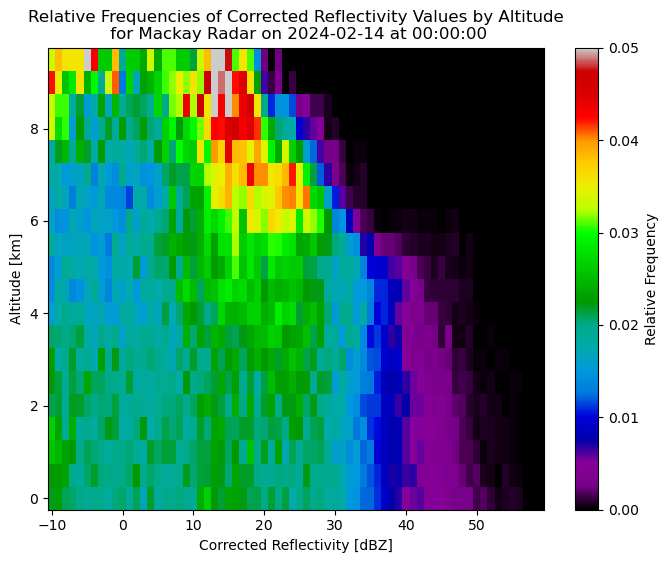

In [53]:
# THIS BLOCK PLOTS A CFAD

DBZs = np.arange(LoEndDBZ,HiEndDBZ,1)          # (X COORDINATE ON THE PLOT) create a list of all possible DBZ values from -39 to 100 in steps of 1 
Heights = np.array(ConsideredHeights) * 0.001  # (Y COORDINATE ON THE PLOT) [converted to km] create a list of all of the altitudes where data are stored

UprightFrequencies = np.transpose(NormCountsGrid) # (VALUES ON THE PLOT) transpose the stored relative frequencies of the reflectivities

# PLOT A CFAD! (sort of)
fig, ax = plt.subplots(figsize=(8,6))

CFAD1 = pcolormeshC(DBZs , Heights, UprightFrequencies, ax=ax, cmap='nipy_spectral', vmin=0, vmax=0.05)
plt.colorbar(CFAD1, ax=ax, label = 'Relative Frequency')

plt.title('Relative Frequencies of Corrected Reflectivity Values by Altitude\n for ' + RadarSiteName + ' Radar on ' + \
          RadarFileDate[0:4] + '-' + RadarFileDate[4:6] + '-' + RadarFileDate[6:8] + ' at ' + \
          str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6]) 

ax.set_xlabel('Corrected Reflectivity [dBZ]')
ax.set_ylabel('Altitude [km]')

In [40]:
'Radar Site ' + str(RadarIDno) + ' on ' + RadarFileDate[0:4] + '-' + RadarFileDate[4:6] + '-' + RadarFileDate[6:8]  + ' at ' + \
         str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6]

'Radar Site 22 on 2024-02-14 at 00:00:00'

In [56]:
goopgoop = xgrids.corrected_reflectivity[0,0,:,:]
    
np.sum(np.isnan(goopgoop))/np.size(goopgoop)

<xarray.DataArray 'corrected_reflectivity' ()> Size: 8B
array(0.36202691)
Coordinates:
    time                        object 8B 2024-02-14 00:04:30
    z                           float64 8B 0.0
    ProjectionCoordinateSystem  int32 4B 1
    projection                  int32 4B 1
    origin_latitude             float32 4B -21.12
    origin_longitude            float32 4B 149.2
    origin_altitude             float32 4B 43.9
Attributes:
    _FillValue:               -32
    calibration_offset:       0
    calibration_units:        dBZ
    calibration_description:  Technique implemented using satellite matching ...
    calibration_comment:      GR_cal = GR - cal_offset
    comment:                  Radar reflectivity has not been corrected for w...
    _Write_as_dtype:          i2

In [63]:
np.size(xgrids.z)

31

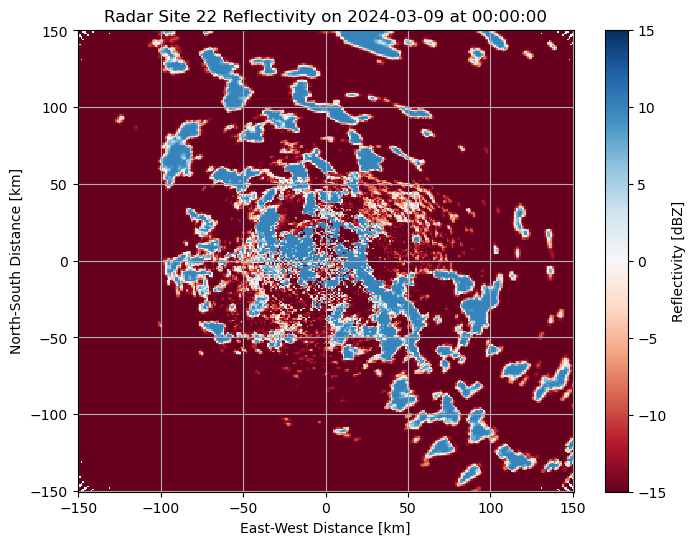

In [23]:
# Create a plot of the differential reflectivity for a 5-min period

fig, ax = plt.subplots(figsize=(8,6))
GridViewer = pcolormeshC(xgrids.x*0.001, xgrids.y*0.001, xgrids.corrected_differential_reflectivity[0,2,:,:], ax=ax, cmap='RdBu', vmin=-15, vmax=15)
# mutiply by 0.001 to get distances in km

ax.set_xlabel('East-West Distance [km]')
ax.set_ylabel('North-South Distance [km]')
plt.title('Radar Site ' + str(RadarIDno) + ' Reflectivity on ' + RadarFileDate[0:4] + '-' + RadarFileDate[4:6] + '-' + RadarFileDate[6:8] + ' at ' + \
          str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6])
plt.colorbar(GridViewer, ax=ax, label = 'Reflectivity [dBZ]')
plt.grid()

# SaveFolder = '/scratch/v46/sg3241/tmp/pngImages/' + RadarIDno + '/' + RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '/'
# SaveFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '_' + GridOrPPI + '500m.png'

# SavePath = SaveFolder + SaveFile

# if not Path(SaveFolder).exists():
#     print('doing')
#     Path(SaveFolder).mkdir(parents=True, exist_ok=True)

# plt.savefig(SavePath, bbox_inches='tight', facecolor='w', dpi = 300)

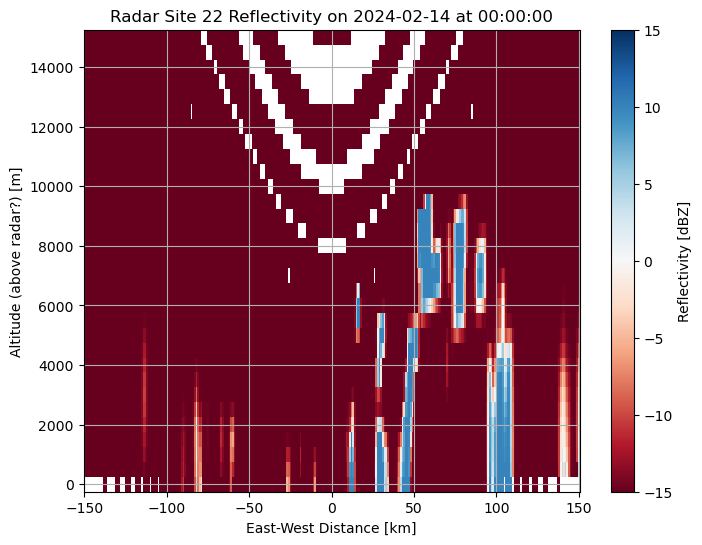

In [10]:
# Create a plot of the differential reflectivity for a 5-min period

fig, ax = plt.subplots(figsize=(8,6))
GridViewer = pcolormeshC(xgrids.x*0.001, xgrids.z, xgrids.corrected_differential_reflectivity[0,:,200,:], ax=ax, cmap='RdBu', vmin=-15, vmax=15)
# mutiply by 0.001 to get distances in km, 150 entry of y is 0 km radar off-set (EAST-WEST CROSS SECTION)

ax.set_xlabel('East-West Distance [km]')
ax.set_ylabel('Altitude (above radar?) [m]')
plt.title('Radar Site ' + str(RadarIDno) + ' Reflectivity on ' + RadarFileDate[0:4] + '-' + RadarFileDate[4:6] + '-' + RadarFileDate[6:8] + ' at ' + \
          str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6])
plt.colorbar(GridViewer, ax=ax, label = 'Reflectivity [dBZ]')
plt.grid()

# SaveFolder = '/scratch/v46/sg3241/tmp/pngImages/' + RadarIDno + '/' + RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '/'
# SaveFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '_' + GridOrPPI + '500m.png'

# SavePath = SaveFolder + SaveFile

# if not Path(SaveFolder).exists():
#     print('doing')
#     Path(SaveFolder).mkdir(parents=True, exist_ok=True)

# plt.savefig(SavePath, bbox_inches='tight', facecolor='w', dpi = 300)

In [ ]:
# ALL IN ONE LOOP!


# THIS BLOCK IS WHERE THE USER PUTS INFO ABOUT THE RADAR

# the reference number for the radar location (ie 20 is Mackay)
RadarIDno = '22'  # 22 is Mackay, 106 is Townsville, 66 is Mt Staplyton (Brisbane) , 50 is Marabong (near Bris)
GridOrPPI = 'ppi'

# the day in consideration (YYYYMMDD) and time (hhmmss)
# ALL IN UTC !!!
RadarYear  = 2024
RadarMonth = 2
RadarDay   = 14

RadarFileDate  = str(RadarYear).zfill(4) + str(RadarMonth).zfill(2) + str(RadarDay).zfill(2)
RadarFileDatePrint = RadarFileDate[0:4] + '-' + RadarFileDate[4:6] + '-' + RadarFileDate[6:8] # add a string of format YYYY-MM-DD for printing



# THIS BLOCK TAKES A ZIPPED FOLDER FROM /G/DATA/ AND UNZIPS IT TO A FOLDER "nzippedRadarFiles" IN SCRATCH

# PATH NAMES
# ZippedFolder = '/g/data/rq0/level_1b/22/ppi/2024/'
ZippedFolder = '/g/data/rq0/level_1b/' + RadarIDno + '/' + GridOrPPI + '/' + str(RadarYear) + '/'
ZippedFile   =  RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '.zip'

# place where the zipped file lives
ZippedPath = ZippedFolder + ZippedFile
# place to extract the files to
ExtractToDirectory = Path('/scratch/v46/sg3241/tmp/UnzippedRadarFiles/' + RadarIDno + '/' + RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '/')

# Create the extraction folder (only if you haven't already)
if not Path(ExtractToDirectory).exists():
    ExtractToDirectory.mkdir(parents=True, exist_ok=True)

    # actually do the unzipping
    with zp.ZipFile(ZippedPath, 'r') as ZipReference:
        ZipReference.extractall(ExtractToDirectory)

    print('Done')
else:
    print('Unzipped Folder Already Exists')


# loop over every 5 min period in the day
for houri in range(0,24):
    for mini in range(0,60,5):
        RadarFileTime = str(houri).zfill(2) + str(mini).zfill(2) + '00' # write out the time in 6 digits (like 012040 for 01:20:40 AM)
        RadarFileTimePrint = str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6] # add a string of format hh:mm:ss for printing
        print('working on ' + RadarFileTime)

        # READ IN THE DATA TO A PYART FILE
        
        # the path of where the UNZIPPED radar data now live
        RadarFolder = '/scratch/v46/sg3241/tmp/UnzippedRadarFiles/' + RadarIDno + '/' + RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '/'
        RadarFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '_' + GridOrPPI + '.nc'
        
        
        # open the radar data 
        RadarPyArt = pyart.io.read(RadarFolder + RadarFile, delay_field_loading = True)
        
        
        # convert the ppi data to a grid
        grids = pyart.map.grid_from_radars(RadarPyArt,(31,301,301),
                           ((0.,15000.),(-150000.,150000.),(-150000.,150000.)),
                           refl_field='corrected_reflectivity', weighting_function='Barnes2')
        
        # convert to an xarray data frame
        xgrids = grids.to_xarray()
        
        
        # Create a plot of the differential reflectivity for a 5-min period
        
        fig, ax = plt.subplots(figsize=(8,6))
        GridViewer = pcolormeshC(xgrids.x*0.001, xgrids.z, xgrids.corrected_reflectivity[0,:,200,:], ax=ax, cmap='nipy_spectral', vmin=-10, vmax=50)
        # mutiply by 0.001 to get distances in km                                        # THIS SLICE COMES FROM 50 KM NORTH OF THE RADAR TO BETTER SEE THE VOLUME
        
        ax.set_xlabel('East-West Distance [km]')
        ax.set_ylabel('Altitude Above Radar [m]')
        plt.title('Radar Site ' + str(RadarIDno) + ' Reflectivity on ' + RadarFileDate[0:4] + '-' + RadarFileDate[4:6] + '-' + RadarFileDate[6:8] + ' at ' + \
                  str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6])
        plt.colorbar(GridViewer, ax=ax, label = 'Reflectivity [dBZ]')
        plt.grid()
        
        PlotType = 'Vert'
        PlotVar  = 'corrected_reflectivity'
        Slice    = '0kmEW'
        
        SaveFolder = '/scratch/v46/sg3241/tmp/pngImages/' + PlotType + '/' + RadarIDno + '/' + RadarFileDate + '/'
        SaveFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '_' + PlotVar + '_' + PlotType + Slice + '.png'
        
        SavePath = SaveFolder + SaveFile
        
        if not Path(SaveFolder).exists():
            print('Creating Folder')
            Path(SaveFolder).mkdir(parents=True, exist_ok=True)
        
        plt.savefig(SavePath, bbox_inches='tight', facecolor='w', dpi = 300)

Unzipped Folder Already Exists
working on 000000
doing
working on 000500
working on 001000
working on 001500
working on 002000
working on 002500


In [12]:
# THIS BLOCK CREATES A GIF FROM THE SAVED RADAR REFLECTIVITY PNG IMAGES
                
# LOADING IMAGES
files = sorted(os.listdir(SaveFolder)) # takes all of the files in the folder in the order they are named
images = [
    Image.open(os.path.join(SaveFolder, f))
    for f in files
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

GIFsaveFolder = '/scratch/v46/sg3241/tmp/gifImages/' + PlotType + '/' + RadarIDno + '/' + RadarFileDate + '/'
GIFsaveFile   = RadarIDno + '_' + RadarFileDate + '_' + PlotVar + '_' + PlotType + Slice + '.gif'

GIFsavePath = GIFsaveFolder + GIFsaveFile

if not Path(GIFsaveFolder).exists():
    Path(GIFsaveFolder).mkdir(parents=True, exist_ok=True)

# Save as looping GIF
images[0].save(
    GIFsavePath,
    save_all=True,
    append_images=images[1:],
    duration=200,    # ms per frame
    loop=0,          # 0 = loop forever
)
print('Saved GIF for ' + RadarFileDatePrint)



Saved GIF for 2024-02-14
